<a href="https://colab.research.google.com/github/sso-eun/2026-01_CV/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

## 이미지 출력 사이즈 조절용
def imshow(title, img, figsize=(6, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.xticks([]), plt.yticks([])
    plt.show()

In [ ]:
img = cv.imread('data/Fig0309(a)(washed_out_aerial_image).tif', cv.IMREAD_GRAYSCALE)
img = cv.resize(img, dsize=(0, 0), fx=0.25, fy=0.25)

In [ ]:
def gamma(f, gamma=1.0):
    f1=f/255.0
    return np.uint8(255*(f1**gamma))

In [ ]:
 gc = np.hstack((gamma(img, 0.5), gamma(img, 0.75), gamma(img, 1.0),gamma(img, 2.0), gamma(img, 3.0)))

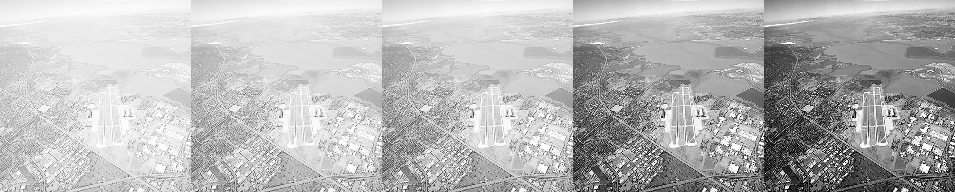

In [ ]:
cv2_imshow(gc)

### **2-1 감마보정 분석결과**
- 감마값이 커질 수록 이미지는 어두워지고, 감마 값이 작아질 수록 이미지는 밝아진다. (제곱하기 때문)
- 따라서, 너무 밝은 사진에 대비를 높여 이미지를 보다 선명하게 할 때 감마값을 크게 넣고 어두운 이미지를 밝게 보정할 때는 감마 값을 작게 넣는다.

In [ ]:
img2 = cv.imread('data/Fig0310(b)(washed_out_pollen_image).tif')
img2 = cv.resize(img2, dsize=(0, 0), fx=0.25, fy=0.25)
img2_gray = cv.cvtColor(img2,cv.COLOR_BGR2GRAY)

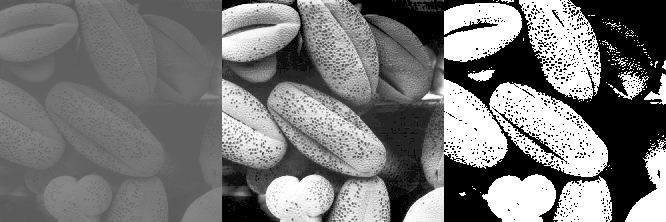

In [ ]:
#Otsu 알고리즘 사용하기
s_img = cv.equalizeHist(img2_gray) #히스토그램 평활화
t, bin_img = cv.threshold(s_img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

show2 = np.hstack((img2_gray, s_img, bin_img))
cv2_imshow(show2)

### **2-2 실험 결과**
- Otsu 알고리즘은 입력된 영상의 히스토그램을 통해 최적의 임계값을 찾는 알고리즘.
- 원본 이미지처럼 선명하지 않은 입력에 사용하여 객체 분리를 명확하게 할 수 있음.

In [ ]:
# 1. 평균 블러 (3x3)
k1 = np.array([[1/9, 1/9, 1/9],
                       [1/9, 1/9, 1/9],
                       [1/9, 1/9, 1/9]], dtype=np.float32)

# 2. 가우시안 블러 (5x5)
k2 = np.array([[0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
               [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
               [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
               [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
               [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]], np.float32)

# 3. 라플라시안 (3x3)
k3 = np.array([[ 0, -1,  0],
               [-1,  4, -1],
               [ 0, -1,  0]], np.float32)

# 4. 라플라시안2 (3x3)
k4 = np.array([[-1, -1, -1],
               [-1,  8, -1],
               [-1, -1, -1]], np.float32)

# 5. 엠보싱 (3x3)
k5 = np.array([[-1,  0,  0],
               [ 0,  0,  0],
               [ 0,  0,  1]], np.float32)

# 6. 엠보싱2 (3x3)
k6 = np.array([[-1, -1,  0],
               [-1,  0,  1],
               [ 0,  1,  1]], np.float32)

=== 원본 이미지 ===


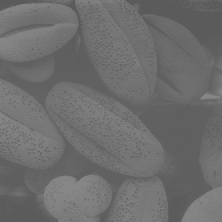

In [ ]:
masks = [k1, k2, k3, k4, k5, k6]
names = ['1. 평균 블러',
         '2. 가우시안 블러',
         '3. 4연결 라플라시안',
         '4. 8연결 라플라시안',
         '5. 엠보싱',
         '6. 엠보싱2']

print("=== 원본 이미지 ===")
cv2_imshow(img2)


=== 1. 평균 블러 ===


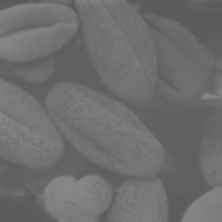


=== 2. 가우시안 블러 ===


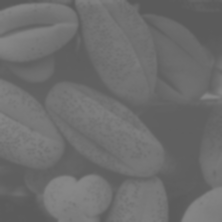


=== 3. 4연결 라플라시안 ===


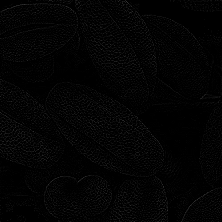


=== 4. 8연결 라플라시안 ===


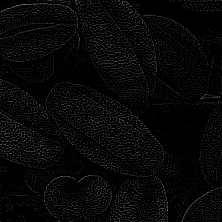


=== 5. 엠보싱 ===


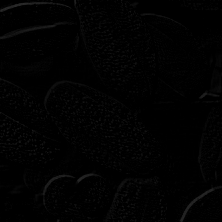


=== 6. 엠보싱2 ===


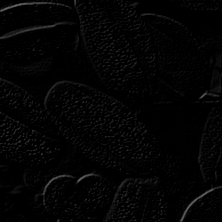

In [ ]:
for mask, name in zip(masks, names):
    result = cv.filter2D(img2, -1, mask)
    print(f"\n=== {name} ===")
    cv2_imshow(result)

### **2-3 결과 분석**
- 평균 블러 : 주변 9개 픽셀 평균을 내서 노이즈 제거
- 가우시안 : 중심에 가까울 수록 가중치가 높고, 평균 블러보다 더 자연스럽다.
- 4연결 라플라시안: 상하좌우 4방향 엣지 검출된다. 배경은 검고 경계선은 밝게 나온다.
- 8연결 라플라시안 : 8방향 모두 엣지 검출되고, 노이즈에 더 민감하다
- 엠보싱(우상단 대각선방향) : 대각선 방향의 밝기 강조.
- 엠보싱2(좌하단 대각선) : 우상단 엠보싱과 반대방향으로 적용

In [ ]:
img4=cv.imread('data/school.jpg')
gray_school = cv.cvtColor(img4, cv.COLOR_BGR2GRAY)

In [ ]:
# 45방향 대각선
d_45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], dtype=np.float32)

d_n45 = np.array([
    [ 0, 1, 2],
    [ -1,  0, 1],
    [ -2,  -1,  0]
], dtype=np.float32)


In [ ]:
result_45  = cv.filter2D(img4, -1, d_45)
result_n45 = cv.filter2D(img4, -1, d_n45)

# 두 결과 합치기 (전체 대각선 엣지)
result_combined = cv.addWeighted(result_45, 0.5, result_n45, 0.5, 0)

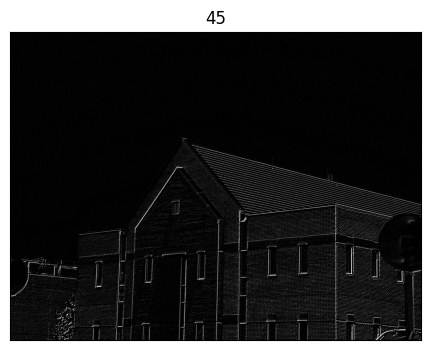

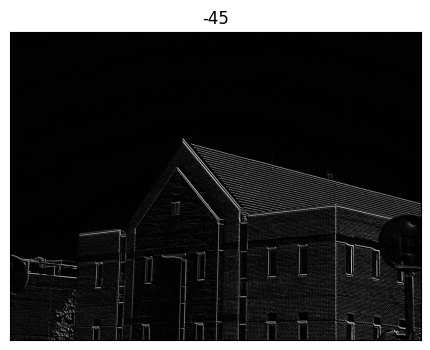

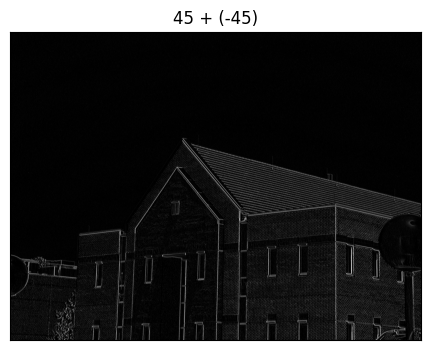

In [ ]:
imshow('45',result_45)
imshow('-45',result_n45)
imshow('45 + (-45)',result_combined)

### **2-4 분석**
- 45도 방향, -45도 방향에서 각 방향의 엣지가 밝게 검출됨
- 즉, 마스크의 방향에 따라 검출되는 엣지 방향이 달라진다.
- 두 방향을 합성하여 출력하면, 수평, 수직 엣지가 밝게 검출됨


In [ ]:
img5 = cv.imread('data/finger.jpg')

In [ ]:
# 1로 채운 사각형 마스크 준비
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
# 오프닝으로 흰 점 제거
opening = cv.morphologyEx(img5, cv.MORPH_OPEN, kernel)

# 클로진으로 끊긴 선 연결
closing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)

# 오프닝>클로징 1회 반복으로는 아직 끊긴 부분이 있다.
# 추가 반복
kernel2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)) # 마스크 크기도 조절

opening2 = cv.morphologyEx(img5, cv.MORPH_OPEN, kernel2, iterations=2)
closing2 = cv.morphologyEx(opening2, cv.MORPH_CLOSE, kernel2, iterations=2)

opening4 = cv.morphologyEx(img5, cv.MORPH_OPEN, kernel2, iterations=4)
closing4 = cv.morphologyEx(opening4, cv.MORPH_CLOSE, kernel2, iterations=4)

opening8 = cv.morphologyEx(img5, cv.MORPH_OPEN, kernel2, iterations=8)
closing8 = cv.morphologyEx(opening4, cv.MORPH_CLOSE, kernel2, iterations=8)

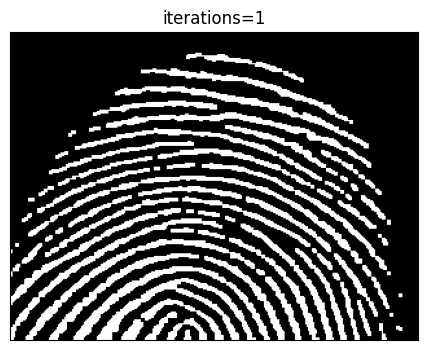

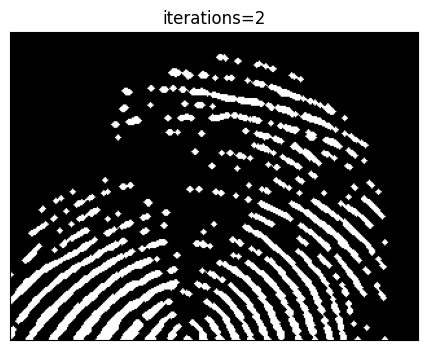

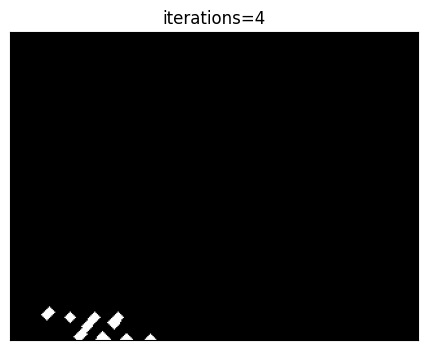

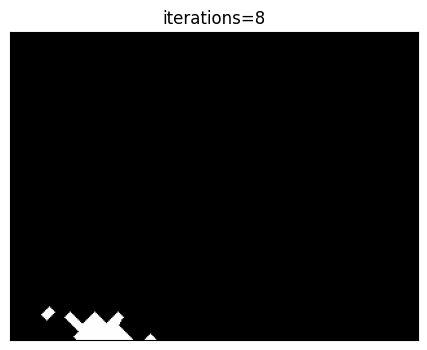

In [ ]:
imshow('iterations=1', closing)
imshow('iterations=2', closing2)
imshow('iterations=4', closing4)
imshow('iterations=8', closing8)

### **2-5 분석**
- 오프닝과 클로징으로 배경의 노이즈(흰점)과 끊긴 부분을 연결함
- 오프닝-클로징 순서를 하나의 반복으로 2배수 씩 반복을 늘렸을 때, 2회차부터는 오히려 이미지의 훼손이 심해짐
- 입력에 사용한 이미지는 1회에서 최대 수렴이 된 것으로 추측 할 수 있음.

In [ ]:
img6 = cv.imread('data/Fig0905(a)(wirebond-mask).tif', cv.IMREAD_GRAYSCALE)
img6 = cv.resize(img6, dsize=(0, 0), fx=0.25, fy=0.25)

In [ ]:
# 살리려는 선
kernel_diag = np.array([ [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0],
                         [0,0,0,1,0,0,0]], np.uint8)

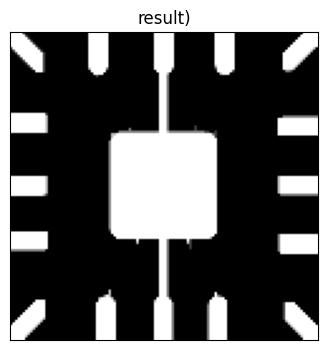

In [ ]:
result = cv.morphologyEx(img6, cv.MORPH_OPEN, kernel_diag)
imshow('result)', result)

### **2-6 결과 분석**
- 12시-6시 방향 수직선만 살리기 위해 마스크에서 수직방향을 1로 설정
- 설정 후 오프닝 연산으로 다른 선을 지움

In [ ]:
img7 = cv.imread('data/Fig0939(a)(headCT-Vandy).tif', cv.IMREAD_GRAYSCALE)
img7 = cv.resize(img7, dsize=(0, 0), fx=0.25, fy=0.25)

In [ ]:
# 소벨 엣지
grad_x=cv.Sobel(img7, cv.CV_32F, 1, 0, ksize=3)
grad_y=cv.Sobel(img7, cv.CV_32F, 0, 1, ksize=3)

sobel_x=cv.convertScaleAbs(grad_x)
sobel_y=cv.convertScaleAbs(grad_y)

edge_strength=cv.addWeighted(sobel_x,0.5,sobel_y,0.5,0) #엣지 강도 계산

In [ ]:
# 라플라시안 2차미분
laplacian = cv.Laplacian(img7, cv.CV_64F, ksize=3)
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

In [ ]:
# 캐니 엣지
canny = cv.Canny(img7, threshold1=50, threshold2=150)

In [ ]:
# 침식팽창
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
morph_gradient = cv.morphologyEx(img7, cv.MORPH_GRADIENT, kernel)


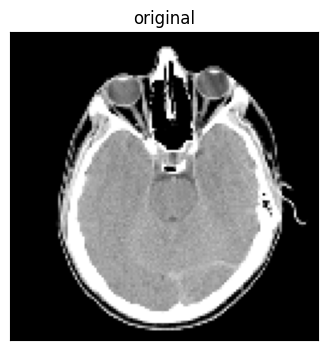

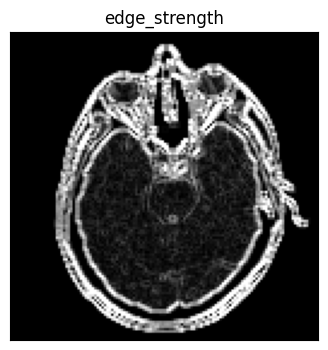

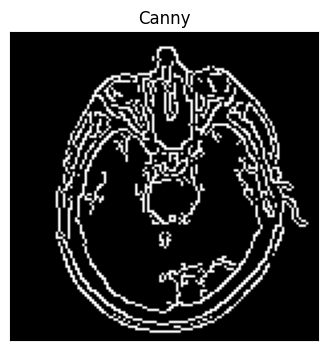

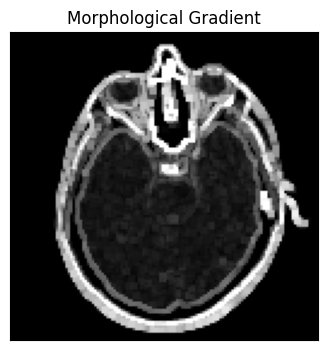

In [ ]:
imshow('original',img7)
imshow('edge_strength',edge_strength)
imshow('Canny', canny)
imshow('Morphological Gradient', morph_gradient)


### **2-7 분석**
- sobel : 외곽선과 내부 경계 검출 가능
- Laplacian : 노이즈에 민감
- Canny : 얇고 깔끔한 엣지. threshold로 민감도 조절 가능
- Morphological Gradient : 엣지가 굵고 섬세하지 않음

In [153]:
img8 = cv.imread('data/Fig0938(a)(cygnusloop_Xray_original).tif', cv.IMREAD_GRAYSCALE)

In [166]:
# Morphological Smoothing
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
morph_open   = cv.morphologyEx(img8, cv.MORPH_OPEN,  kernel,iterations=1)
morph_smooth = cv.morphologyEx(morph_open, cv.MORPH_CLOSE, kernel,iterations=1)

In [170]:
# Smoothing Filter
blur_avg = cv.blur(img8, (7, 7))

#가우시안 블러
# blur_gaussian = cv.GaussianBlur(img8, (7, 7), 0)

#미디안 블러
# blur_median = cv.medianBlur(img8, 7)

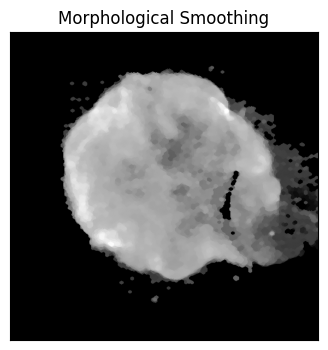

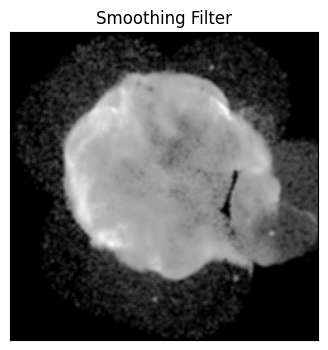

In [171]:
imshow('Morphological Smoothing', morph_smooth)
imshow('Smoothing Filter', blur_avg)
# imshow('gaussian', blur_gaussian)
# imshow('median', blur_median)

### **2-8 분석 결과**
- Morphological Smoothing :픽셀의 형태와 구조를 보고 노이즈를 제거함
- Smoothing Filter : 픽셀값과 주변의 평균을 내서 노이즈를 제거함. 그래서 엣지가 흐릿해짐


In [180]:
img9 = cv.imread('data/Fig0940(a)(rice_image_with_intensity_gradient).tif', cv.IMREAD_GRAYSCALE)

In [181]:
img9 = cv.resize(img9, dsize=(0, 0), fx=0.5, fy=0.5)

In [182]:
# 1) Otsu만 하기
_, otsu = cv.threshold(img9, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)


In [190]:
# 2) top-hat 후 Otsu 하기
kernel = cv.getStructuringElement(cv.MORPH_RECT, (50, 50))  # 쌀알보다 커널 크게
tophat = cv.morphologyEx(img9, cv.MORPH_TOPHAT, kernel)


_, otsu_tophat = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)


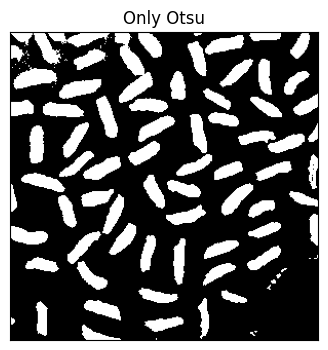

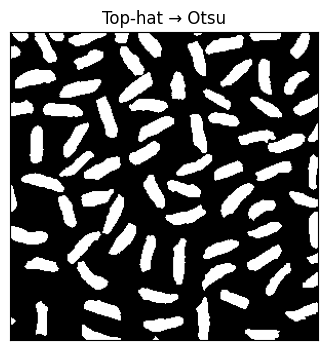

In [191]:
imshow('Only Otsu', otsu)
# imshow('Top-hat result', tophat)
imshow('Top-hat → Otsu', otsu_tophat)

### **2-9 분석**
- 원본이미지 : 배경과 쌀알이 어둡게 나오는 영역이 있음
- Otsu : Otsu만 했을 때는, 어두운 쪽의 쌀알이 배경으로 분류되어 검출할 수 없음
- top-hat 후 Otsu : 어두운 쪽의 쌀알까지 검출 가능

In [238]:
img10 = cv.imread('data/Fig0943(a)(dark_blobs_on_light_background).tif', cv.IMREAD_GRAYSCALE)
# imshow('(a) 원본', img10)

In [239]:
k_close = cv.getStructuringElement(cv.MORPH_ELLIPSE, (55, 55)) # 50까지는 좌측부분에 작은 원형도 남음
closing = cv.morphologyEx(img10, cv.MORPH_CLOSE, k_close)


In [240]:
k_open = cv.getStructuringElement(cv.MORPH_ELLIPSE, (110, 110)) # 55보다 크게 2배 넣어봄
opening = cv.morphologyEx(closing, cv.MORPH_OPEN, k_open)


In [241]:
k_grad = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
gradient = cv.morphologyEx(opening, cv.MORPH_GRADIENT, k_grad)

In [242]:
overlay = img10.copy()
overlay[gradient > 0] = 255

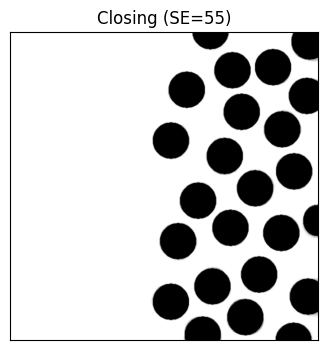

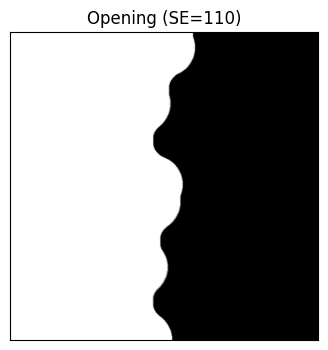

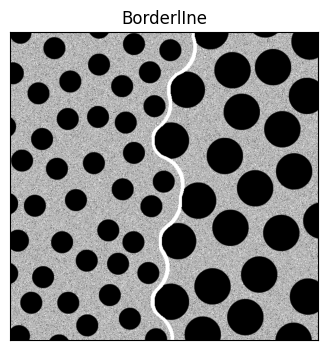

In [246]:
imshow('Closing (SE=55)', closing)
imshow('Opening (SE=110)', opening)
imshow('BorderlIne', overlay)

### **2-10 분석하기**
- closing : 50까지는 작은 원형 크기보다 SE가 커서 작은 원들이 검출됨.
- Opening : 큰 원형 크기 구역에서 밝은 배경이 제거되고, 하나로 합쳐짐.
- Borderline : 팽창-침식을 이용하여 영역의 경계선 도출